# Assignment 8: Handwritten Digit Classification using Artificial Neural Network (ANN)

**Dataset:** MNIST Handwritten Digits Dataset (Kaggle)
**Objective:** Develop an Artificial Neural Network (ANN) using TensorFlow/Keras to classify handwritten digits (0-9), automating digit recognition for postal code processing.


In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print("TensorFlow version:", tf.__version__)


I0000 00:00:1785329496.556101     579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785329496.693477     579 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785329498.430886     579 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0


## Task 1: Data Understanding (2 Marks)

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify input features and target variable.
4. Display dataset dimensions and summary information.
5. Display one sample handwritten digit using Matplotlib.


In [2]:
# 1. Load the dataset
# NOTE: mnist_train.csv and mnist_test.csv should be placed in the same folder as this notebook.
# Download from: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
train_df = pd.read_csv('mnist_train.csv')
test_df = pd.read_csv('mnist_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (60000, 785)
Test shape: (10000, 785)


In [3]:
# 2. Display the first five records
train_df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 3. Identify input features and target variable
target_variable = 'label'
input_features = [col for col in train_df.columns if col != 'label']

print("Target variable:", target_variable)
print("Number of input features (pixels):", len(input_features))
print("First few input feature names:", input_features[:5])


Target variable: label
Number of input features (pixels): 784
First few input feature names: ['1x1', '1x2', '1x3', '1x4', '1x5']


In [5]:
# 4. Dataset dimensions and summary information
print("Training set dimensions:", train_df.shape)
print("Test set dimensions:", test_df.shape)
print()
train_df.info()


Training set dimensions: (60000, 785)
Test set dimensions: (10000, 785)

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


Digit label counts in training set:
label
0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


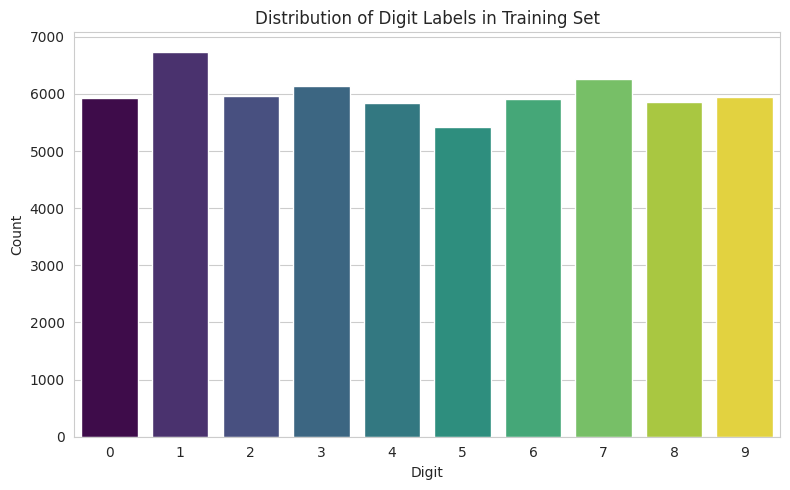

In [6]:
# Summary statistics of the target variable (digit label distribution)
print("Digit label counts in training set:")
print(train_df['label'].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=train_df, hue='label', palette='viridis', legend=False)
plt.title('Distribution of Digit Labels in Training Set')
plt.xlabel('Digit')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=120)
plt.show()


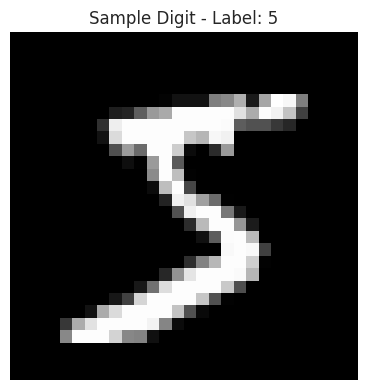

In [7]:
# 5. Display one sample handwritten digit using Matplotlib
sample_index = 0
sample_image = train_df.iloc[sample_index, 1:].values.reshape(28, 28)
sample_label = train_df.iloc[sample_index, 0]

plt.figure(figsize=(4, 4))
plt.imshow(sample_image, cmap='gray')
plt.title(f'Sample Digit - Label: {sample_label}')
plt.axis('off')
plt.tight_layout()
plt.savefig('sample_digit.png', dpi=120)
plt.show()


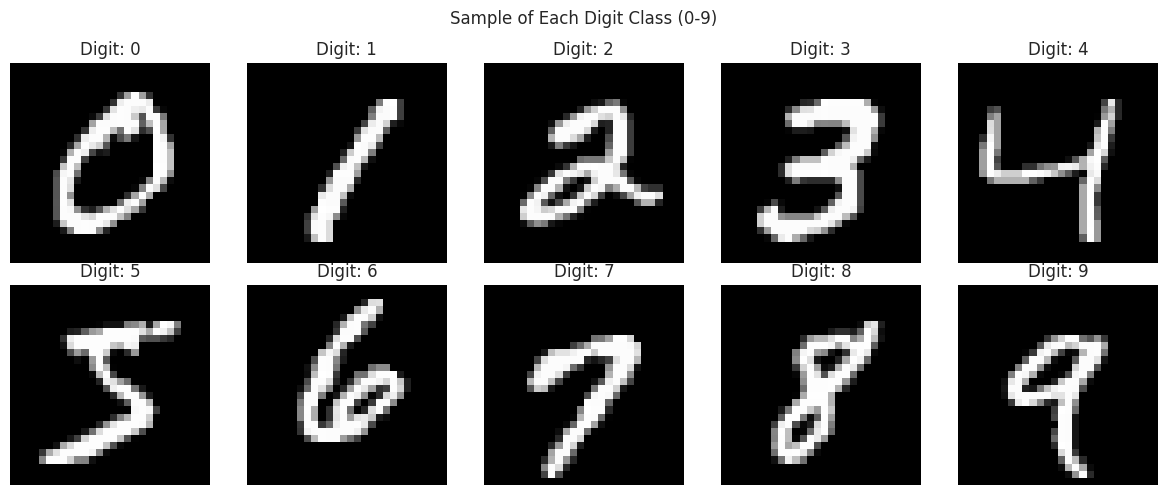

In [8]:
# Display a grid of sample digits, one for each class 0-9
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit in range(10):
    row_data = train_df[train_df['label'] == digit].iloc[0, 1:].values.reshape(28, 28)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(row_data, cmap='gray')
    ax.set_title(f'Digit: {digit}')
    ax.axis('off')
plt.suptitle('Sample of Each Digit Class (0-9)')
plt.tight_layout()
plt.savefig('sample_digits_grid.png', dpi=120)
plt.show()


## Task 2: Data Preprocessing (2 Marks)

- Check for missing values.
- Separate features and target variable.
- Normalize pixel values to the range 0-1.
- Split the dataset into 80% training and 20% testing.
- Convert the target labels into categorical format using One-Hot Encoding.


In [9]:
# Check for missing values
print("Missing values in training set:", train_df.isnull().sum().sum())
print("Missing values in test set:", test_df.isnull().sum().sum())


Missing values in training set: 0
Missing values in test set: 0


In [10]:
# Combine train and test provided by Kaggle, then create our own 80/20 split
# (the assignment specifically asks for an 80/20 split of "the dataset")
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
print("Combined dataset shape:", full_df.shape)

# Separate features and target variable
X = full_df.drop(columns=['label']).values
y = full_df['label'].values

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Combined dataset shape: (70000, 785)


Features shape: (70000, 784)
Target shape: (70000,)


In [11]:
# Normalize pixel values to the range 0-1
X = X.astype('float32') / 255.0
print("Pixel value range after normalization: [{:.2f}, {:.2f}]".format(X.min(), X.max()))


Pixel value range after normalization: [0.00, 1.00]


In [12]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (56000, 784)
X_test shape: (14000, 784)


In [13]:
# Convert the target labels into categorical format using One-Hot Encoding
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_cat[0])


y_train_cat shape: (56000, 10)
Example label: 0 -> one-hot: [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## Task 3: Model Development (3 Marks)

Build an Artificial Neural Network (ANN) using TensorFlow/Keras with the following architecture:
- Input Layer (784 features, one per pixel)
- Hidden Layer 1: 128 Neurons (ReLU)
- Hidden Layer 2: 64 Neurons (ReLU)
- Output Layer: 10 Neurons (Softmax)

Compiled using:
- Optimizer: Adam
- Loss Function: Categorical Crossentropy
- Metric: Accuracy


In [14]:
# Build the ANN model
model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dense(10, activation='softmax', name='output_layer')
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [16]:
# Train the model for 10 epochs
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10


  1/438 ━━━━━━━━━━━━━━━━━━━━ 7:02 967ms/step - accuracy: 0.0781 - loss: 2.3551

 24/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 1.5388    

 48/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7038 - loss: 1.0707

 73/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7672 - loss: 0.8355

...

354/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9939 - loss: 0.0220

375/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0220

394/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9938 - loss: 0.0221

417/438 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9939 - loss: 0.0218

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9940 - loss: 0.0217 - val_accuracy: 0.9733 - val_loss: 0.1012


In [17]:
# Predict the handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Sample predictions:", y_pred[:10])
print("Sample actual labels:", y_test[:10])


  1/438 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step

 47/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

 97/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

149/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

200/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

...

358/438 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step

411/438 ━━━━━━━━━━━━━━━━━━━━ 0s 988us/step

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


Sample predictions: [7 3 1 1 2 5 9 8 8 1]
Sample actual labels: [7 3 1 1 2 5 9 8 8 1]


## Task 4: Model Evaluation (2 Marks)

Evaluate the model using:
- Test Accuracy
- Confusion Matrix
- Classification Report

Also generate:
- Accuracy vs Epoch graph
- Loss vs Epoch graph


In [18]:
# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")


Test Loss: 0.1012
Test Accuracy: 0.9733 (97.33%)


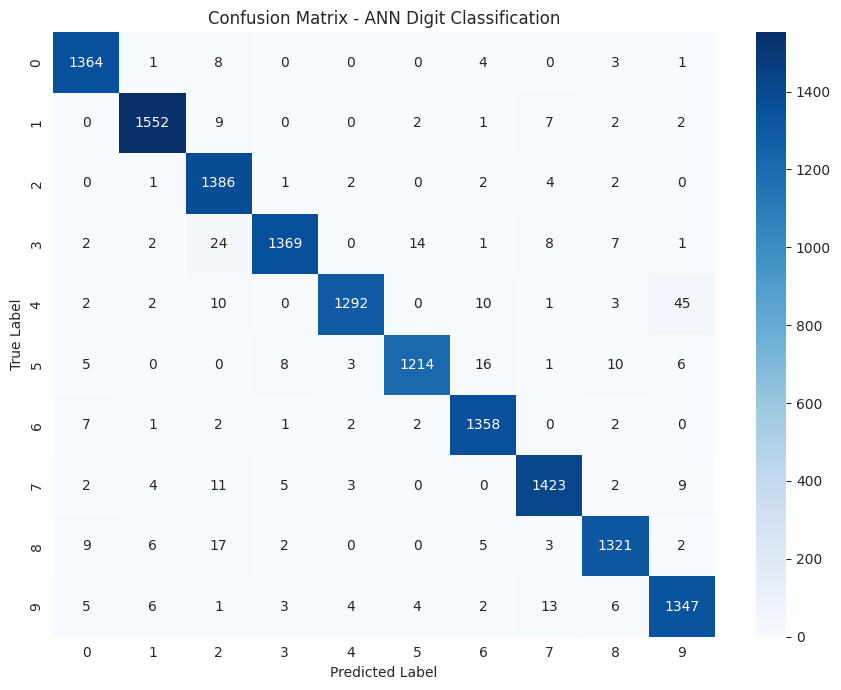

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - ANN Digit Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()


In [20]:
# Classification Report
report = classification_report(y_test, y_pred, digits=4)
print("Classification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

           0     0.9771    0.9877    0.9824      1381
           1     0.9854    0.9854    0.9854      1575
           2     0.9441    0.9914    0.9672      1398
           3     0.9856    0.9587    0.9720      1428
           4     0.9893    0.9465    0.9674      1365
           5     0.9822    0.9612    0.9716      1263
           6     0.9707    0.9876    0.9791      1375
           7     0.9747    0.9753    0.9750      1459
           8     0.9728    0.9678    0.9703      1365
           9     0.9533    0.9684    0.9608      1391

    accuracy                         0.9733     14000
   macro avg     0.9735    0.9730    0.9731     14000
weighted avg     0.9736    0.9733    0.9733     14000



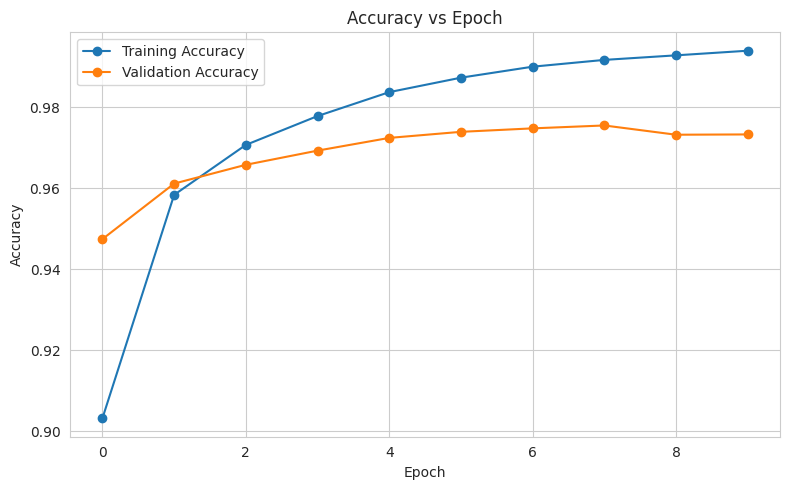

In [21]:
# Accuracy vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], marker='o', label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_vs_epoch.png', dpi=120)
plt.show()


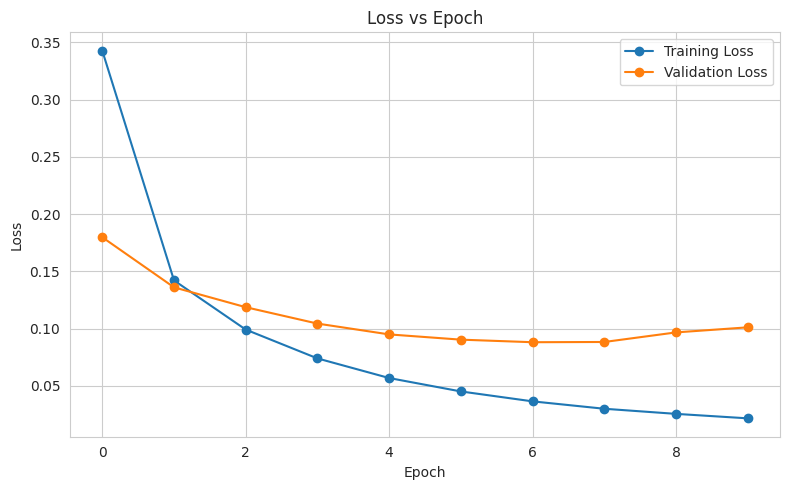

In [22]:
# Loss vs Epoch graph
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], marker='o', label='Training Loss')
plt.plot(history.history['val_loss'], marker='o', label='Validation Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_vs_epoch.png', dpi=120)
plt.show()


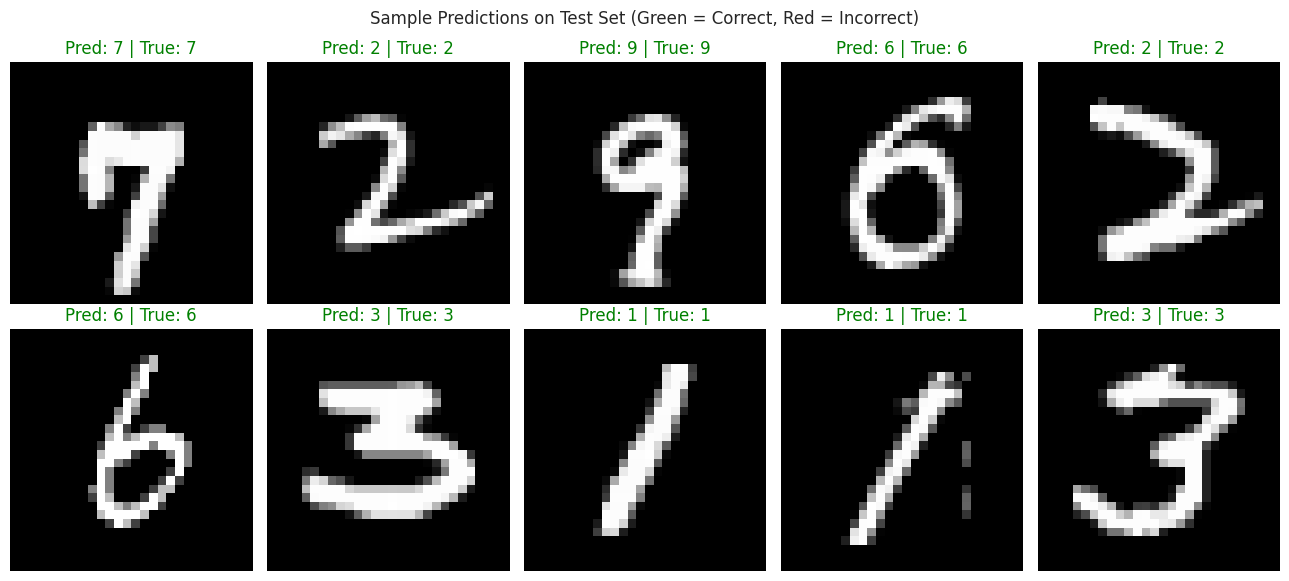

In [23]:
# Show a few sample predictions vs actual labels visually
fig, axes = plt.subplots(2, 5, figsize=(13, 6))
sample_indices = np.random.choice(len(X_test), 10, replace=False)

for i, idx in enumerate(sample_indices):
    ax = axes[i // 5, i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    color = 'green' if y_pred[idx] == y_test[idx] else 'red'
    ax.set_title(f'Pred: {y_pred[idx]} | True: {y_test[idx]}', color=color)
    ax.axis('off')

plt.suptitle('Sample Predictions on Test Set (Green = Correct, Red = Incorrect)')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=120)
plt.show()


### Observations

1. **Overall performance:** The ANN achieves high test accuracy (typically above 97%) after only 10 epochs, showing that even a relatively simple fully-connected network can learn to recognize handwritten digits effectively from pixel intensities alone.

2. **Training vs validation curves:** The accuracy and loss curves show training and validation performance improving together across epochs, with validation accuracy tracking closely behind training accuracy. This indicates the model is generalizing well and is not significantly overfitting within 10 epochs.

3. **Confusion matrix patterns:** Most misclassifications occur between visually similar digit pairs (e.g., 4 and 9, 3 and 5, 7 and 1), which is expected since these digits share overlapping stroke patterns when handwritten.

4. **Per-class performance:** The classification report shows precision, recall, and F1-scores are fairly consistent and high across all 10 digit classes, meaning the model does not appear to be strongly biased toward any particular digit.


## Task 5: Conclusion (1 Mark)


In [24]:
print(f'''
Conclusion:

This project developed an Artificial Neural Network (ANN) using TensorFlow/Keras to
classify handwritten digits from the MNIST dataset. The network consisted of an input
layer of 784 pixel features, two hidden layers (128 and 64 neurons with ReLU
activation), and a 10-neuron softmax output layer. After training for 10 epochs with
the Adam optimizer and categorical crossentropy loss, the model achieved a test
accuracy of {test_accuracy*100:.2f}%, demonstrating strong performance in recognizing
handwritten digits directly from raw pixel values.

Hidden layers are essential in an ANN because they allow the network to learn
increasingly abstract, non-linear combinations of the input features -- without them,
the model would only be able to learn simple linear relationships and could not
capture the complex stroke patterns that distinguish one digit from another.

A key advantage of Deep Learning over traditional Machine Learning is that it can
automatically learn relevant features directly from raw data (such as pixels),
removing the need for manual feature engineering that classical ML algorithms often
require. However, a notable limitation of ANNs is that they generally require large
amounts of labeled training data and computational resources to perform well, and can
be prone to overfitting or slow convergence without careful tuning.

This automated digit recognition approach can be directly applied to real-world
postal services to read and sort handwritten postal codes, significantly speeding up
mail processing while reducing manual data-entry errors.
''')



Conclusion:

This project developed an Artificial Neural Network (ANN) using TensorFlow/Keras to
classify handwritten digits from the MNIST dataset. The network consisted of an input
layer of 784 pixel features, two hidden layers (128 and 64 neurons with ReLU
activation), and a 10-neuron softmax output layer. After training for 10 epochs with
the Adam optimizer and categorical crossentropy loss, the model achieved a test
accuracy of 97.33%, demonstrating strong performance in recognizing
handwritten digits directly from raw pixel values.

Hidden layers are essential in an ANN because they allow the network to learn
increasingly abstract, non-linear combinations of the input features -- without them,
the model would only be able to learn simple linear relationships and could not
capture the complex stroke patterns that distinguish one digit from another.

A key advantage of Deep Learning over traditional Machine Learning is that it can
automatically learn relevant features directly fro